# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv 


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж 
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

In [644]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
# < напишите код здесь > 

df = pd.read_csv("travel insurance.csv")
# url = "https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv"
# df = pd.read_csv(url)

In [646]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB


In [647]:
# получаем категориальные и числовые столбцы для удобства
cat_features_mask = (df.dtypes == "object").values
cat_columns = df.columns[cat_features_mask]
num_columns = df.columns[~cat_features_mask]
cat_columns

Index(['Agency', 'Agency Type', 'Distribution Channel', 'Product Name',
       'Claim', 'Destination', 'Gender'],
      dtype='object')

In [648]:
# уникальные объекты в категориальных столбцах
for column in cat_columns:
    print(f"\n{column}: {df[column].nunique()} ")
    print(df[column].unique())


Agency: 16 
['CBH' 'CWT' 'JZI' 'KML' 'EPX' 'C2B' 'JWT' 'RAB' 'SSI' 'ART' 'CSR' 'CCR'
 'ADM' 'LWC' 'TTW' 'TST']

Agency Type: 2 
['Travel Agency' 'Airlines']

Distribution Channel: 2 
['Offline' 'Online']

Product Name: 26 
['Comprehensive Plan' 'Rental Vehicle Excess Insurance' 'Value Plan'
 'Basic Plan' 'Premier Plan' '2 way Comprehensive Plan' 'Bronze Plan'
 'Silver Plan' 'Annual Silver Plan' 'Cancellation Plan'
 '1 way Comprehensive Plan' 'Ticket Protector' '24 Protect' 'Gold Plan'
 'Annual Gold Plan' 'Single Trip Travel Protect Silver'
 'Individual Comprehensive Plan' 'Spouse or Parents Comprehensive Plan'
 'Annual Travel Protect Silver' 'Single Trip Travel Protect Platinum'
 'Annual Travel Protect Gold' 'Single Trip Travel Protect Gold'
 'Annual Travel Protect Platinum' 'Child Comprehensive Plan'
 'Travel Cruise Protect' 'Travel Cruise Protect Family']

Claim: 2 
['No' 'Yes']

Destination: 149 
['MALAYSIA' 'AUSTRALIA' 'ITALY' 'UNITED STATES' 'THAILAND'
 "KOREA, DEMOCRATIC PEOPLE'

In [649]:
df["Claim"].value_counts()

Claim
No     62399
Yes      927
Name: count, dtype: int64

Довольно много "no", то есть нужно сделать downsampling, чтобы избавиться от дизбаланса классов

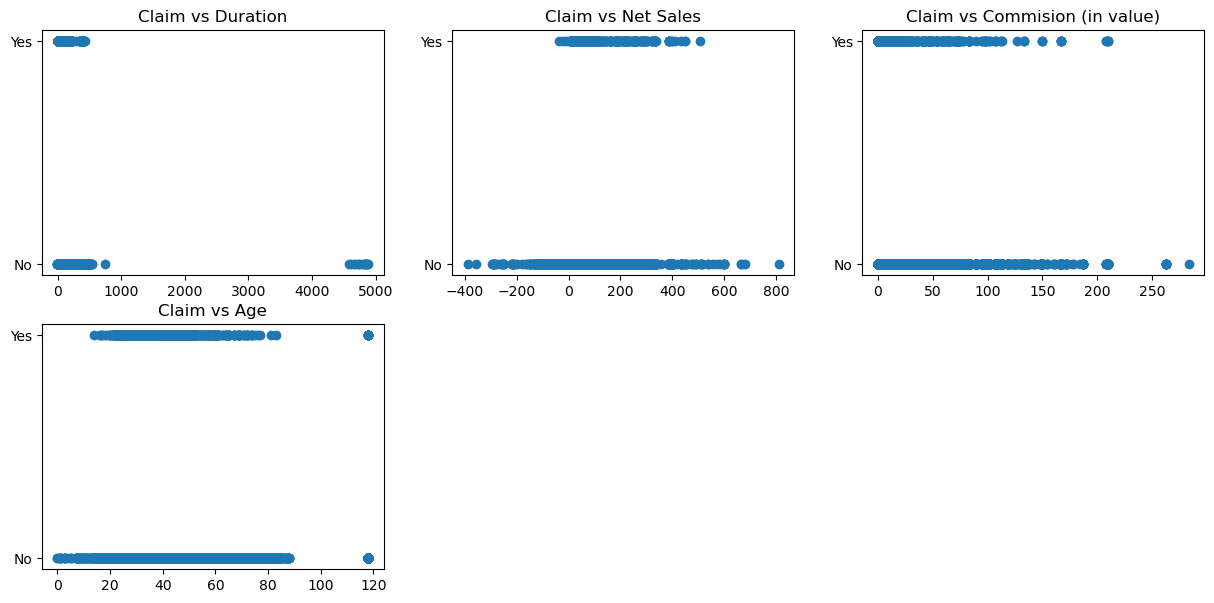

In [650]:
# соотношение таргета и разных числовых фичей
plt.figure(figsize=(15, 7))

plt.subplot(231)
plt.scatter(df["Duration"], df["Claim"])
plt.title("Claim vs Duration")

plt.subplot(232)
plt.scatter(df["Net Sales"], df["Claim"])
plt.title("Claim vs Net Sales")

plt.subplot(233)
plt.scatter(df["Commision (in value)"], df["Claim"])
plt.title("Claim vs Commision (in value)")

plt.subplot(234)
plt.scatter(df['Age'], df["Claim"])
plt.title("Claim vs Age")

plt.show()

Выглядит криво, но понятно, что у нас есть какие-то выбросы в данных, которые надо устранить (например в duration)

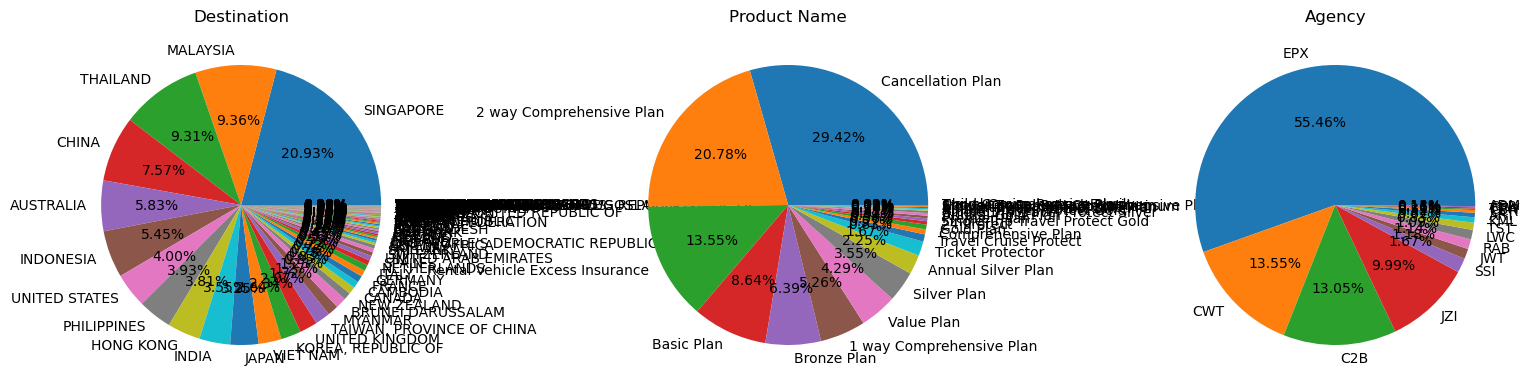

In [651]:
plt.figure(figsize = (20,10))

plt.subplot(231)
plt.pie(df['Destination'].value_counts(), labels = df['Destination'].value_counts().index, autopct = '%1.2f%%')
plt.title('Destination')

plt.subplot(232)
plt.pie(df['Product Name'].value_counts(), labels = df['Product Name'].value_counts().index, autopct = '%1.2f%%')
plt.title('Product Name')

plt.subplot(233)
plt.pie(df['Agency'].value_counts(), labels = df['Agency'].value_counts().index, autopct = '%1.2f%%')
plt.title('Agency')

plt.show()

Интересная статистика (по столбцам):

так как Destination довольно разношёрстный предлагаю его не учитывать

Product Name можно оставить топ 8, а остальные заменить на others

в Агенствах можно оставить топ 4, а остальные соответственно заменить на others

И наконец-то обработка

Уберём nan

In [ ]:
# количество nan
print(df.isna().sum())
print("\n", len(df["Gender"]))


Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64

 63326


так как Nan больше, чем обычных значений в Gender, то тогда смысла нет учитывать этот столбец

In [653]:
# удаляем столбец Gender
df = df.drop("Gender", axis=1)

Числовые признаки:

In [654]:
# собственно чистка выбросов

df = df[df["Duration"] >= 0]
df = df[df["Duration"] < 1000]

df = df[df["Net Sales"] >= -200]
df = df[df["Net Sales"] <= 600]

df = df[df["Commision (in value)"] >= 0]
df = df[df["Commision (in value)"] <= 175]

df = df[df["Age"] >= 5]
df = df[df["Age"] <= 90]

In [655]:
# minmax_scale из прошлых заданий
def minmax_scale(arr):
    xmin = arr.min(axis=0)
    xmax = arr.max(axis=0)
    
    xdel = np.array([(el == 0) * 1 + el for el in list(xmax - xmin)])

    return (arr - xmin) / xdel

In [656]:
# обрабатываем числовые признаки
num_columns = df.columns[df.dtypes != "object"]
num_array = df[num_columns].values
num_array_scaled = minmax_scale(num_array)
df[num_columns] = num_array_scaled

In [657]:
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,0.251351,MALAYSIA,0.212045,0.055556,0.915663
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,0.251351,MALAYSIA,0.212045,0.055556,0.795181
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,0.087838,AUSTRALIA,0.186324,0.172414,0.325301
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,0.081081,AUSTRALIA,0.198745,0.137931,0.325301
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,0.106757,ITALY,0.223588,0.068966,0.433735


Теперь категориальные признаки

In [658]:
# преобразуем признаки с двумя значениями в 0/1
df["Agency Type"] = np.where(df["Agency Type"] == "Travel Agency", 0, 1)
df["Distribution Channel"] = np.where(df["Distribution Channel"] == "Offline", 0, 1)
df["Claim"] = np.where(df["Claim"] == "Yes", 1, 0)

In [659]:
# Убираем столбец Destination (говорил об этом выше)
df = df.drop("Destination", axis=1)

In [660]:
# onehot_encoding из прошлых заданий
def onehot_encoding(arr):
    un = np.unique(arr)
    n = len(np.unique(arr))
    m = {}
    i = 0

    for el in un:
        m[el] = i
        i += 1

    res = np.zeros((len(arr), len(un)), int)
    for i in range(len(arr)):
        res[i][m[arr[i]]] = 1
    
    return res

In [661]:
# Берём топ 8 признаков Product Name, а остальные комбинируем
top_products = df["Product Name"].value_counts().head(8).index

df["Product Name"] = df["Product Name"].apply(
    lambda x: f"Product Name {x}" if x in top_products else "Other Product Name"
)

In [662]:
# Берём топ 4 признаков Product Name, а остальные комбинируем
top_agencies = df["Agency"].value_counts().head(4).index

df["Agency"] = df["Agency"].apply(
    lambda x: f"Agency {x}" if x in top_agencies else "Other Agency"
)

In [663]:
# применяем onehot_encoding
agency_encoded = onehot_encoding(df["Agency"].values)
product_encoded = onehot_encoding(df["Product Name"].values)

unique_agency = np.unique(df["Agency"].values)
unique_product = np.unique(df["Product Name"].values)

In [664]:
# выделяем признаки, которые не изменяем
not_onehot_df = df.drop(["Agency", "Product Name"], axis=1)

In [665]:
# скеиваем в общую таблицу
agency_df = pd.DataFrame(
    agency_encoded, 
    columns=unique_agency,
    index=df.index
)

product_df = pd.DataFrame(
    product_encoded,
    columns=unique_product,
    index=df.index
)

df = pd.concat([not_onehot_df, agency_df, product_df], axis=1)

In [666]:
# и напишем функцию для балансировки классов
def balanced(df, desired_ratio = 0.30):
    df_0 = df[df['Claim'] == 0]
    df_1 = df[df['Claim'] == 1]

    n_1 = len(df_1)
    n_total = int(n_1 / desired_ratio)
    n_0_new = n_total - n_1

    df_0_down = df_0.sample(n=n_0_new, random_state=42)

    df = pd.concat([df_0_down, df_1]).sample(frac=1, random_state=42)
    return df

In [667]:
# отлично
df.head()

,Agency Type,Distribution Channel,Claim,Duration,Net Sales,Commision (in value),Age,Agency C2B,Agency CWT,Agency EPX,Agency JZI,Other Agency,Other Product Name,Product Name 1 way Comprehensive Plan,Product Name 2 way Comprehensive Plan,Product Name Basic Plan,Product Name Bronze Plan,Product Name Cancellation Plan,Product Name Rental Vehicle Excess Insurance,Product Name Silver Plan,Product Name Value Plan
0,0,0,0,0.251351,0.212045,0.055556,0.915663,0,0,0,0,1,1,0,0,0,0,0,0,0,0
1,0,0,0,0.251351,0.212045,0.055556,0.795181,0,0,0,0,1,1,0,0,0,0,0,0,0,0
2,0,1,0,0.087838,0.186324,0.172414,0.325301,0,1,0,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0.081081,0.198745,0.137931,0.325301,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0,1,0,0.106757,0.223588,0.068966,0.433735,0,1,0,0,0,0,0,0,0,0,0,1,0,0


<Axes: >

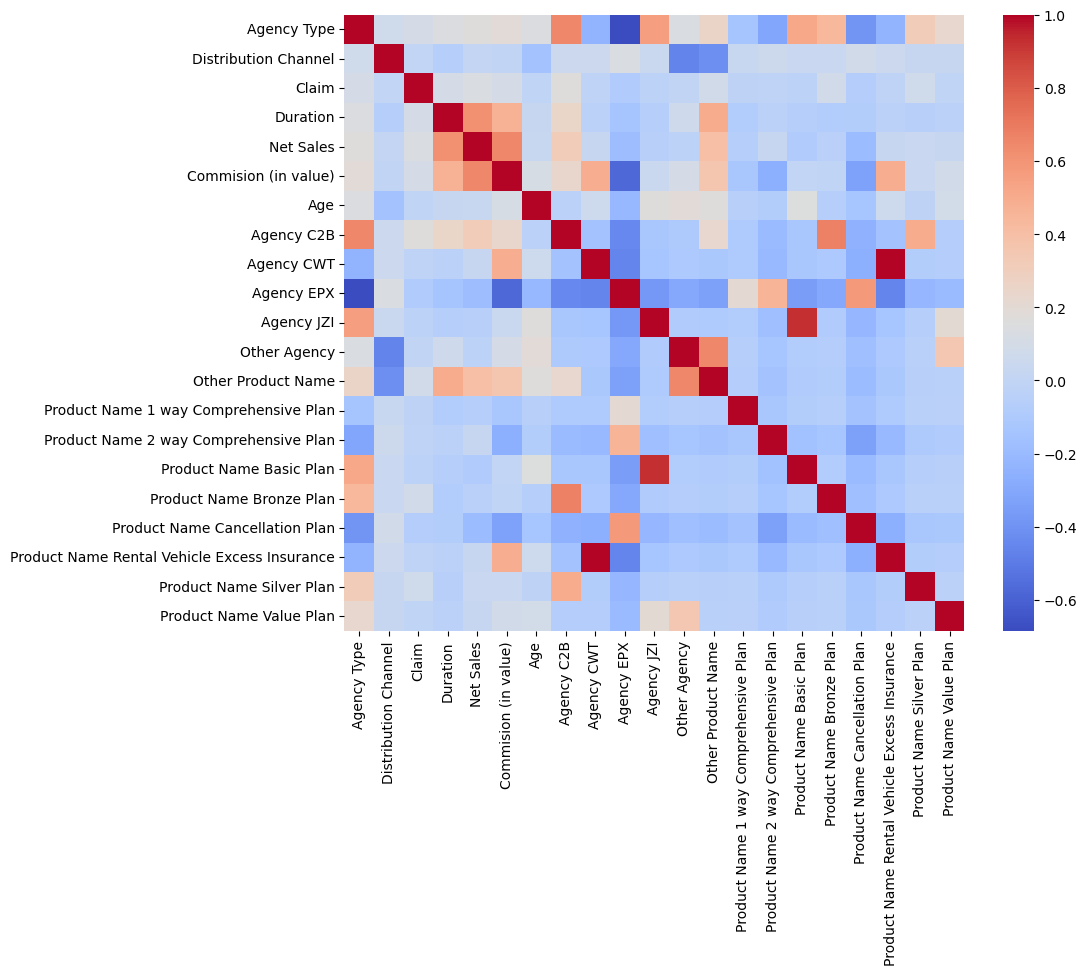

In [668]:
# проверим на мультиколениарность
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')

In [669]:
# удаляем самые красные столбцы (после one hot encoding), чтобы избежать линейной зависимости

df = df.drop(["Product Name Basic Plan", "Agency CWT"], axis=1)

<Axes: >

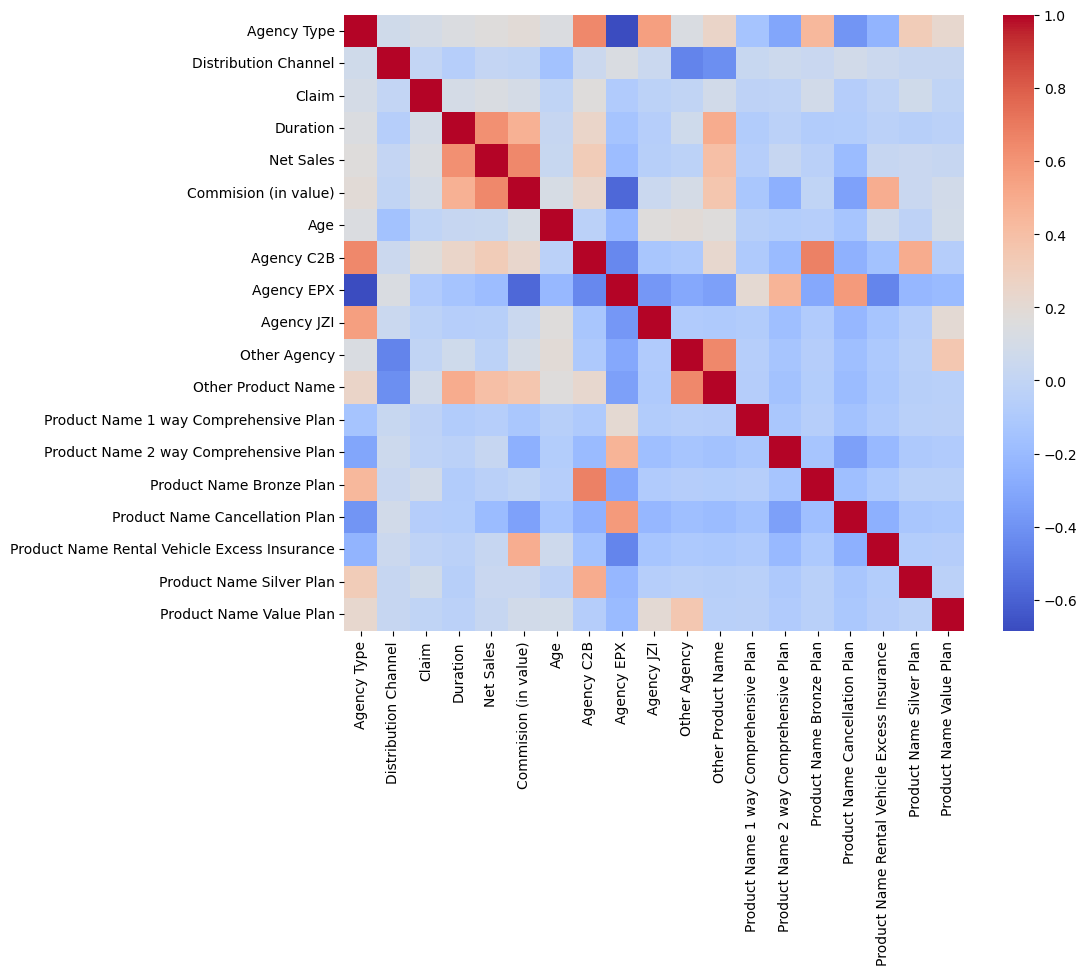

In [670]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')

хотя это только частично помогло, так как у нас остались ещё ярко синяя точка, что плохо

Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели. 

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

1, 2, 3 мы сделали выше,
а разницу в классах мы немного отрегулируем позже в тренировочном датасете

In [671]:
# отделим таргет
y = df["Claim"]
df = df.drop("Claim", axis=1)

In [672]:
# ну и наконец-то приравниваем наш прекрасный датасет к X
X = df

### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2. 

In [673]:
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report

In [674]:
# обработка датасета, создание выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

train_df = pd.concat([X_train, y_train], axis=1)
train_df = balanced(train_df)
y_train = train_df["Claim"]
X_train = train_df.drop("Claim", axis=1)
y_train.shape

(2473,)

2400... Довольно плохо, посмотрим, что с самой моделью будет

In [675]:
# тестовый запуск, проверим веса 

X_train_np = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
X_test_np  = np.hstack([np.ones((X_test.shape[0], 1)), X_test.values])

y_train_np = y_train.values
y_test_np = y_test.values

w = np.linalg.inv(X_train_np.T @ X_train_np) @ X_train_np.T @ y_train_np

print("Аналитическое решение:")
print(f"Среднее значение весов (w_analytic): {w.mean():.4f}")
print(f"Веса: {w}\n")

X_train_np = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
X_test_np  = np.hstack([np.ones((X_test.shape[0], 1)), X_test.values])

y_train_np = y_train.values
y_test_np = y_test.values

lambda_ = 1.0

I = np.eye(X_train_np.shape[1])
I[0, 0] = 0

w_l2 = np.linalg.inv(X_train_np.T @ X_train_np + lambda_ * I) @ X_train_np.T @ y_train_np

print("Решение с L2-регуляризацией:")
print(f"Среднее значение весов (w_reg): {w_l2.mean():.4f}")
print(f"Веса: {w_l2}")

Аналитическое решение:
Среднее значение весов (w_analytic): -0.2057
Веса: [  1.70051174  -1.24726323  -0.90607948 -13.93031643  -3.5919851
  12.45996961  -0.14134632   1.81016484   4.84491228   0.71807865
  -2.08944204   3.40076227  -3.38588179  -1.54390757   0.41307039
  -2.43878051  -0.51445591   0.433126     0.10085669]

Решение с L2-регуляризацией:
Среднее значение весов (w_reg): 0.0890
Веса: [-0.00434299 -0.21382918  0.1039118   0.14176629  0.77947153  0.24363984
 -0.15923048  0.22093377 -0.12165906  0.06585836 -0.05685043  0.17626997
 -0.10663474  0.06490775  0.32415562 -0.07993207 -0.10828264  0.34707996
  0.07384776]


Довольно неплохо, веса < 10 у обычного аналитического решения, то есть downscaling помог

Теперь проверим 50 выборок и вычислим средние метрики

In [676]:
# посчитать аналитическое решение

def analytical_reg(X_train, X_test, y_train):
    X_train_np = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
    X_test_np  = np.hstack([np.ones((X_test.shape[0], 1)), X_test.values])

    y_train_np = y_train.values
    w = np.linalg.inv(X_train_np.T @ X_train_np) @ X_train_np.T @ y_train_np

    y_analitical_final = X_test_np @ w

    y_analitical_final = np.round(y_analitical_final)
    y_analitical_final = np.clip(y_analitical_final, 0, 1)

    return y_analitical_final

In [677]:
# посчитать аналитическое решение с регуляризацией

def analytical_reg_l2(X_train, X_test, y_train):
    X_train_np = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
    X_test_np  = np.hstack([np.ones((X_test.shape[0], 1)), X_test.values])

    y_train_np = y_train.values
    
    lambda_ = 1.0

    I = np.eye(X_train_np.shape[1])
    I[0, 0] = 0

    w_l2 = np.linalg.inv(X_train_np.T @ X_train_np + lambda_ * I) @ X_train_np.T @ y_train_np

    y_analitical_final_l2 = X_test_np @ w_l2

    y_analitical_final_l2 = np.round(y_analitical_final_l2)
    y_analitical_final_l2 = np.clip(y_analitical_final_l2, 0, 1)

    return y_analitical_final_l2

Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [678]:
# обучите модель линейной регрессии LinearRegression на обучающей выборке, примените к тестовой
from sklearn.linear_model import LinearRegression

def sklearn_reg(X_train, X_test, y_train):
    sklearn_linear_regressor = LinearRegression()
    sklearn_linear_regressor.fit(X_train, y_train)

    return sklearn_linear_regressor.predict(X_test)

In [679]:
# обучите модель линейной регрессии Ridge на обучающей выборке, примените к тестовой

from sklearn.linear_model import Ridge

def sklearn_reg_l2(X_train, X_test, y_train):
    sklearn_linear_regressor_l2 = Ridge()
    sklearn_linear_regressor_l2.fit(X_train, y_train)

    return sklearn_linear_regressor_l2.predict(X_test)

In [680]:
def evaluate_model(y_true, y_pred_prob):
    
    y_pred = np.round(y_pred_prob)
    y_pred = np.clip(y_pred, 0, 1)
    
    mse = mean_squared_error(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)
        
    return {
        "mse": mse,
        "cm": cm,
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"]
    }

In [681]:
# результаты без downscaling
results_not_ds = {
    "analytical": [],
    "analytical_l2": [],
    "sklearn": [],
    "sklearn_l2": []
}

for i in range(50):

    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

    # train_df = pd.concat([X_train, y_train], axis=1)
    # train_df = balanced(train_df)
    # y_train = train_df["Claim"]
    # X_train = train_df.drop("Claim", axis=1)

    try:
        predict = analytical_reg(X_train, X_test, y_train)
        results_not_ds["analytical"].append(evaluate_model(y_test.values, predict))
    except np.linalg.LinAlgError:
        ...
    
    results_not_ds["analytical_l2"].append(evaluate_model(y_test.values, analytical_reg_l2(X_train, X_test, y_train)))
    results_not_ds["sklearn"].append(evaluate_model(y_test.values, sklearn_reg(X_train, X_test, y_train)))
    results_not_ds["sklearn_l2"].append(evaluate_model(y_test.values, sklearn_reg_l2(X_train, X_test, y_train)))
    


/home/dlanb/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dlanb/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dlanb/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dlanb/.

In [682]:
# результаты с downscaling
results = {
    "analytical": [],
    "analytical_l2": [],
    "sklearn": [],
    "sklearn_l2": []
}

for i in range(50):

    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

    train_df = pd.concat([X_train, y_train], axis=1)
    train_df = balanced(train_df)
    y_train = train_df["Claim"]
    X_train = train_df.drop("Claim", axis=1)

    try:
        predict = analytical_reg(X_train, X_test, y_train)
        results["analytical"].append(evaluate_model(y_test.values, predict))
    except np.linalg.LinAlgError:
        ...
    
    results["analytical_l2"].append(evaluate_model(y_test.values, analytical_reg_l2(X_train, X_test, y_train)))
    results["sklearn"].append(evaluate_model(y_test.values, sklearn_reg(X_train, X_test, y_train)))
    results["sklearn_l2"].append(evaluate_model(y_test.values, sklearn_reg_l2(X_train, X_test, y_train)))
    


/home/dlanb/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dlanb/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dlanb/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dlanb/.

In [683]:
# модель без downscaling
for model_name in results_not_ds:
    print("\n", model_name.upper())
    
    mse = np.mean([r["mse"] for r in results_not_ds[model_name]])
    precision = np.mean([r["precision"] for r in results_not_ds[model_name]])
    recall = np.mean([r["recall"] for r in results_not_ds[model_name]])
    f1 = np.mean([r["f1"] for r in results_not_ds[model_name]])

    # берём рандомную cm 
    for r in results_not_ds[model_name]:
        cm = r["cm"]
        break

    print("MSE:", mse)
    print("Precision (class 1):", precision)
    print("Recall (class 1):", recall)
    print("F1-score (class 1):", f1)
    print(f"\nConfusion Matrix for {model_name}:")
    print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")


 ANALYTICAL
MSE: 0.05020732883317262
Precision (class 1): 0.02001061911841976
Recall (class 1): 0.05888531036423835
F1-score (class 1): 0.015749456409126773

Confusion Matrix for analytical:
TN: 12246 | FP: 25
FN: 169 | TP: 4

 ANALYTICAL_L2
MSE: 0.014596592735454836
Precision (class 1): 0.0
Recall (class 1): 0.0
F1-score (class 1): 0.0

Confusion Matrix for analytical_l2:
TN: 12271 | FP: 0
FN: 173 | TP: 0

 SKLEARN
MSE: 0.014596592735454836
Precision (class 1): 0.0
Recall (class 1): 0.0
F1-score (class 1): 0.0

Confusion Matrix for sklearn:
TN: 12271 | FP: 0
FN: 173 | TP: 0

 SKLEARN_L2
MSE: 0.014596592735454836
Precision (class 1): 0.0
Recall (class 1): 0.0
F1-score (class 1): 0.0

Confusion Matrix for sklearn_l2:
TN: 12271 | FP: 0
FN: 173 | TP: 0


Результаты без downscaling ужасные, так как модель просто перестала находить класс 1

In [684]:
# модель c downscaling
for model_name in results:
    print("\n", model_name.upper())
    
    mse = np.mean([r["mse"] for r in results[model_name]])
    precision = np.mean([r["precision"] for r in results[model_name]])
    recall = np.mean([r["recall"] for r in results[model_name]])
    f1 = np.mean([r["f1"] for r in results[model_name]])

    # берём рандомную(первую) cm 
    for r in results[model_name]:
        cm = r["cm"]
        break

    print("MSE:", mse)
    print("Precision (class 1):", precision)
    print("Recall (class 1):", recall)
    print("F1-score (class 1):", f1)
    print(f"\nConfusion Matrix for {model_name}:")
    print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")


 ANALYTICAL
MSE: 0.465401800064288
Precision (class 1): 0.02001995675616365
Recall (class 1): 0.5060350348477666
F1-score (class 1): 0.03396558927405607

Confusion Matrix for analytical:
TN: 10423 | FP: 1844
FN: 169 | TP: 8

 ANALYTICAL_L2
MSE: 0.13108807457409194
Precision (class 1): 0.06626575305363003
Recall (class 1): 0.6102151380023209
F1-score (class 1): 0.11949337251050472

Confusion Matrix for analytical_l2:
TN: 10702 | FP: 1565
FN: 64 | TP: 113

 SKLEARN
MSE: 0.13091288974606236
Precision (class 1): 0.06624228901023471
Recall (class 1): 0.60895150940997
F1-score (class 1): 0.11942746487232973

Confusion Matrix for sklearn:
TN: 10717 | FP: 1550
FN: 65 | TP: 112

 SKLEARN_L2
MSE: 0.13108807457409194
Precision (class 1): 0.06626575305363003
Recall (class 1): 0.6102151380023209
F1-score (class 1): 0.11949337251050472

Confusion Matrix for sklearn_l2:
TN: 10702 | FP: 1565
FN: 64 | TP: 113


### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?

**Подытожим:**

Мы провели предобработку: убрали малоинформативные признаки (Gender, Destination), сгруппировали редкие категории в Other, применили One-Hot Encoding (и убрали один столбец, но это не до конца исправило проблему необратимости) и Min-Max Scaling, а также категории с двумя различными признаками сделали, как 0 и 1. Это позволило перевести качественные данные в количественные, пригодные для регрессии.

А также добавили downscaling, это конечно очень сильно уменьшило тренировочную выборку до (3000 элементов, что очень мало), но убрало дизбаланс классов, которые приводил к занулению предсказаний и метрик

**А что там по метрикам и самой модели с downscaling?**

На первый взгляд, значения MSE (0.13 – 0.35) довольно плохие. Модель научилась хорошо предсказывать нули (но гораздо хуже), но все еще ошибается на целевом классе.

Без регуляризации аналитическая модель ведет себя нестабильно: MSE в три раза выше (0.35), а Recall ниже. Как и ожидалось, регуляризация (L2) не только решила проблему необратимости матриц после OHE, но и улучшила предсказания.

Sklearn vs Analytical: Реализация через sklearn и наше аналитическое решение с L2 выдают практически идентичные результаты, что показывает: наша математическая логика работает на уровне библиотечных алгоритмов

Анализ Confusion Matrix (Самое важное):

Несмотря на низкий MSE, мы видим:

    Высокий Recall (61%): Модель успешно находит больше половины реальных страховых случаев (Claims). Для меня это неплохой результат

    Низкий Precision (6.6%): У нас очень много ложноположительных срабатываний (FP ≈1500). То есть модель склонна галюционировать и назначать страховку там, где её нет.

    Малая тестовая выборка: Модель все еще борется с тем, что примеров очень мало (очень часто ошибается), но эффект downscaling дало очень положительный

То есть модель сейчас работает относительно удачно